<a href="https://colab.research.google.com/github/harshithareddy888/PortifolioProjects/blob/main/Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#installing packages
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)


In [2]:
#read the data
from google.colab import files
uploaded = files.upload()

df= pd.read_csv('movies.csv')

Saving movies.csv to movies.csv


In [3]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# checking for missing data
for col in df.columns:
  pct_missing = np.mean(df[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [5]:
#data types of our columns
df.dtypes

,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [6]:
#conversion of datatypes of cols
df['budget'] = df['budget'].fillna(0).astype('int64')
df['gross'] = df['gross'].fillna(0).astype('int64')
df['votes'] = df['votes'].fillna(0).astype('int64')
df['released'] = df['released'].fillna(0).astype(str).str[:4]


In [7]:
#create correct year column
df['correctYear']=df['year']
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctYear
0,The Shining,R,Drama,1980,June,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,July,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,June,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,July,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,July,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,Octo,3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90.0,2020
7664,Dream Round,NaN,Comedy,2020,Febr,4.7,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,0,0,Cactus Blue Entertainment,90.0,2020
7665,Saving Mbango,NaN,Drama,2020,Apri,5.7,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,0,Embi Productions,NaN,2020
7666,It's Just Us,NaN,Drama,2020,Octo,NaN,0,James Randall,James Randall,Christina Roz,United States,15000,0,NaN,120.0,2020


In [8]:
df.sort_values(by=['gross'],inplace=True, ascending=False)
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctYear
5445,Avatar,PG-13,Action,2009,Dece,7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,Apri,8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,Dece,7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,Dece,7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,Apri,8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,Octo,3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90.0,2020
641,Blame It on the Night,PG-13,Comedy,1984,Nove,5.1,172,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85.0,1984
7658,Black Wall Street Burning,R,Drama,2020,Febr,6.6,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78.0,2020
671,Flesh+Blood,R,Adventure,1985,Augu,6.7,17000,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126.0,1985


In [12]:
#drop duplicates
df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctYear
5445,Avatar,PG-13,Action,2009,Dece,7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,Apri,8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,Dece,7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,Dece,7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,Apri,8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,Octo,3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90.0,2020
641,Blame It on the Night,PG-13,Comedy,1984,Nove,5.1,172,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85.0,1984
7658,Black Wall Street Burning,R,Drama,2020,Febr,6.6,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78.0,2020
671,Flesh+Blood,R,Adventure,1985,Augu,6.7,17000,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126.0,1985


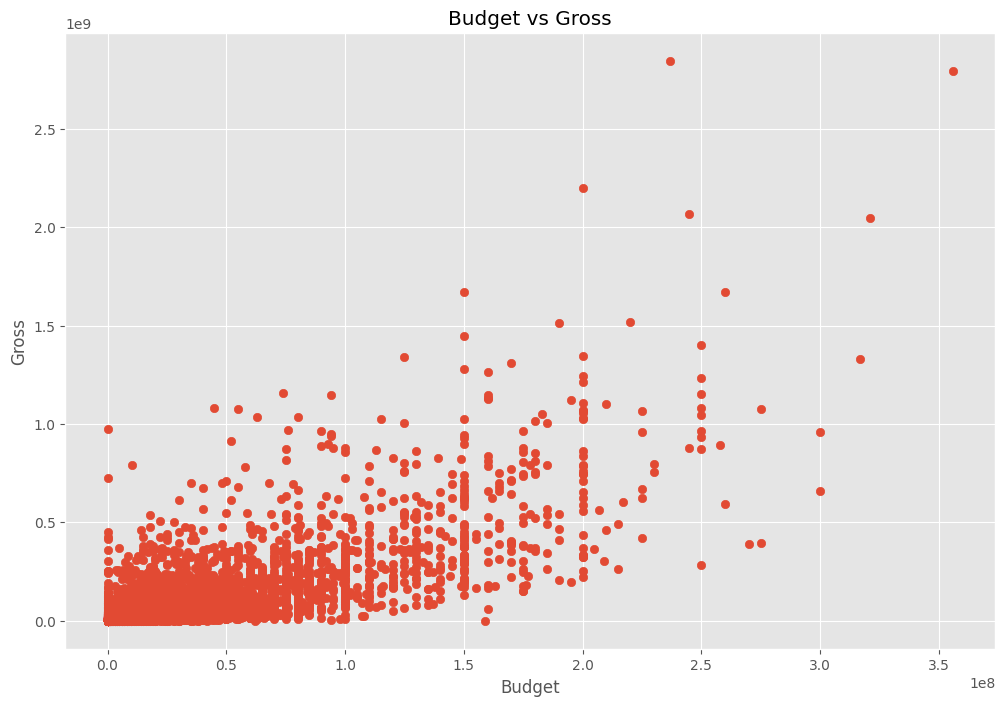

In [23]:
#budget high correlation
#company high correlation

#scatter plot with budget vs gross

plt.scatter(x=df['budget'],y=df['gross'])
plt.title('Budget vs Gross')
plt.xlabel('Budget')
plt.ylabel('Gross')
plt.show()

<Axes: xlabel='budget', ylabel='gross'>

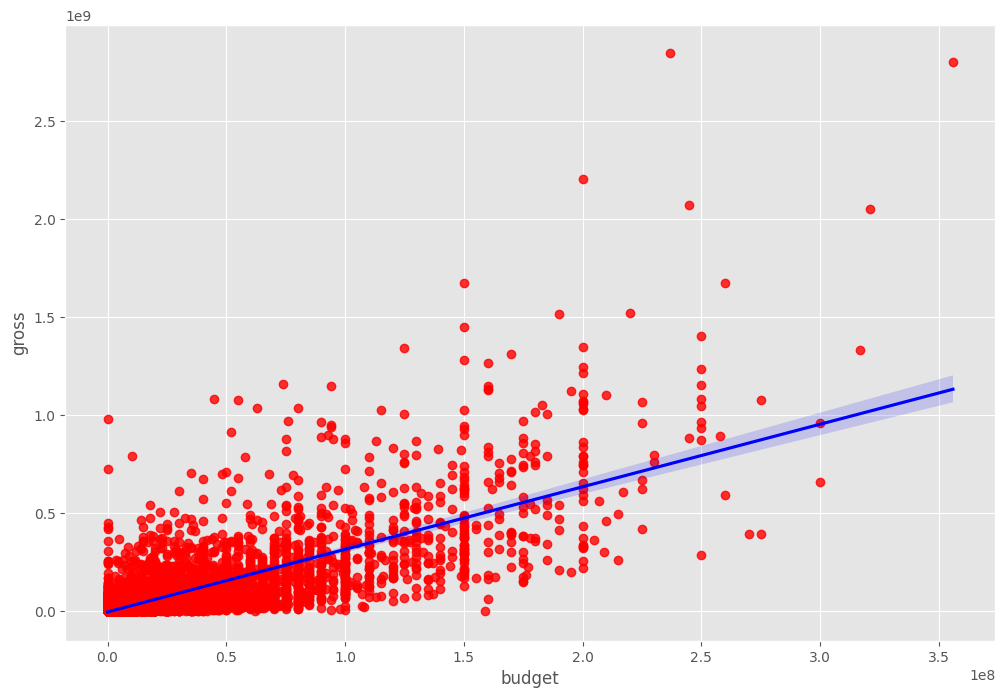

In [26]:
#plot budget vs gross using seaborn
sns.regplot(x='budget',y='gross',data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'})

In [34]:
# Find correlations
# df.corr()  # This line caused the error
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr(method='pearson')

#three types (methods) of correlation - pearson (default one), kendall, spearman
#they have different way of determining correlation


,year,score,votes,budget,gross,runtime,correctYear
year,1.000000,0.097995,0.222427,0.309212,0.261900,0.120811,1.000000
score,0.097995,1.000000,0.409182,0.055665,0.186392,0.399451,0.097995
votes,0.222427,0.409182,1.000000,0.486931,0.632870,0.309122,0.222427
budget,0.309212,0.055665,0.486931,1.000000,0.750157,0.269510,0.309212
gross,0.261900,0.186392,0.632870,0.750157,1.000000,0.245235,0.261900
runtime,0.120811,0.399451,0.309122,0.269510,0.245235,1.000000,0.120811
correctYear,1.000000,0.097995,0.222427,0.309212,0.261900,0.120811,1.000000


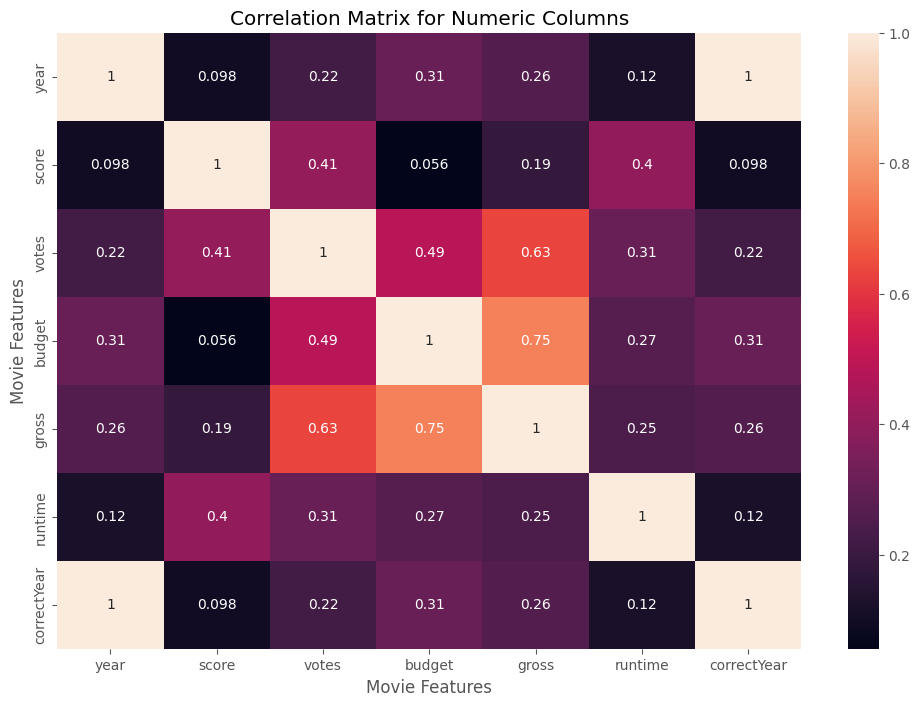

In [40]:
# high correlaton btw budget and gross
correlation_matrix= df_numeric.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix for Numeric Columns')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [42]:
#looking at company
df.head()
#company is not numeric but we can convert it
df_numerized=df
for col_name in df_numerized.columns:
  if(df_numerized[col_name].dtype=='object'):
    df_numerized[col_name]=df_numerized[col_name].astype('category')
    df_numerized[col_name]=df_numerized[col_name].cat.codes
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctYear
5445,533,5,0,2009,11,7.8,1100000,1155,1778,2334,55,237000000,2847246203,2253,162.0,2009
7445,535,5,0,2019,9,8.4,903000,162,743,2241,55,356000000,2797501328,1606,181.0,2019
3045,6896,5,6,1997,11,7.8,1100000,1155,1778,1595,55,200000000,2201647264,2253,194.0,1997
6663,5144,5,0,2015,11,7.8,876000,1125,2550,524,55,245000000,2069521700,1540,138.0,2015
7244,536,5,0,2018,9,8.4,897000,162,743,2241,55,321000000,2048359754,1606,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,-1,6,2020,19,3.1,18,1500,2289,2421,55,7000,0,-1,90.0,2020
641,812,5,4,1984,18,5.1,172,944,1447,1990,55,0,0,833,85.0,1984
7658,798,6,6,2020,12,6.6,35,1769,1069,531,55,5000,0,1748,78.0,2020
671,2019,6,1,1985,10,6.7,17000,2154,1491,2304,33,6500000,0,1977,126.0,1985


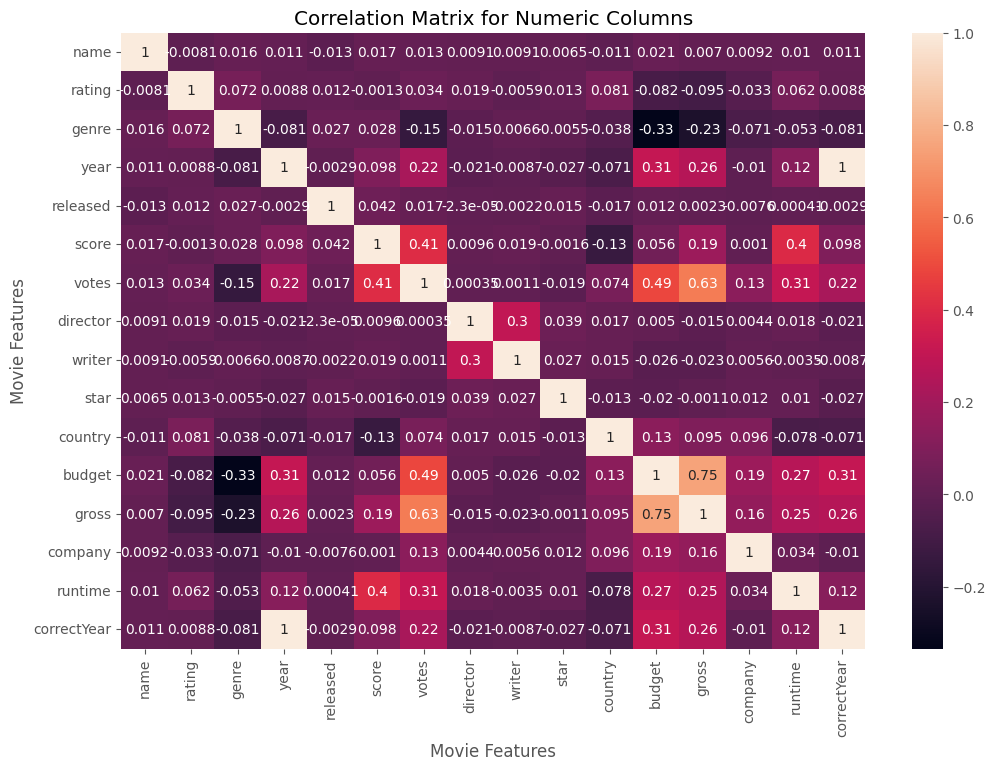

In [43]:
correlation_matrix= df_numerized.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix for Numeric Columns')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [44]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctYear
name,1.000000,-0.008069,0.016355,0.011453,-0.013132,0.017097,0.013038,0.009079,0.009081,0.006472,-0.010737,0.020548,0.006989,0.009211,0.010392,0.011453
rating,-0.008069,1.000000,0.072423,0.008779,0.012429,-0.001314,0.033743,0.019483,-0.005921,0.013405,0.081244,-0.081939,-0.095450,-0.032943,0.062145,0.008779
genre,0.016355,0.072423,1.000000,-0.081261,0.027305,0.027965,-0.145296,-0.015258,0.006567,-0.005477,-0.037615,-0.334021,-0.234297,-0.071067,-0.052711,-0.081261
year,0.011453,0.008779,-0.081261,1.000000,-0.002885,0.097995,0.222427,-0.020795,-0.008656,-0.027242,-0.070938,0.309212,0.261900,-0.010431,0.120811,1.000000
released,-0.013132,0.012429,0.027305,-0.002885,1.000000,0.042020,0.016978,-0.000023,-0.002235,0.015330,-0.017117,0.011545,0.002322,-0.007622,0.000410,-0.002885
score,0.017097,-0.001314,0.027965,0.097995,0.042020,1.000000,0.409182,0.009559,0.019416,-0.001609,-0.133348,0.055665,0.186392,0.001030,0.399451,0.097995
votes,0.013038,0.033743,-0.145296,0.222427,0.016978,0.409182,1.000000,0.000349,0.001127,-0.019146,0.073525,0.486931,0.632870,0.133457,0.309122,0.222427
director,0.009079,0.019483,-0.015258,-0.020795,-0.000023,0.009559,0.000349,1.000000,0.299067,0.039234,0.017490,0.004976,-0.014916,0.004404,0.017624,-0.020795
writer,0.009081,-0.005921,0.006567,-0.008656,-0.002235,0.019416,0.001127,0.299067,1.000000,0.027245,0.015343,-0.025911,-0.022997,0.005646,-0.003511,-0.008656
star,0.006472,0.013405,-0.005477,-0.027242,0.015330,-0.001609,-0.019146,0.039234,0.027245,1.000000,-0.012998,-0.019952,-0.001129,0.012442,0.010174,-0.027242


In [45]:
correlation_mat=df_numerized.corr()
corr_pairs=correlation_mat.unstack()
corr_pairs

name         name           1.000000
             rating        -0.008069
             genre          0.016355
             year           0.011453
             released      -0.013132
                              ...   
correctYear  budget         0.309212
             gross          0.261900
             company       -0.010431
             runtime        0.120811
             correctYear    1.000000
Length: 256, dtype: float64

In [46]:
sorted_pairs=corr_pairs.sort_values()
sorted_pairs

genre        budget        -0.334021
budget       genre         -0.334021
gross        genre         -0.234297
genre        gross         -0.234297
             votes         -0.145296
                              ...   
gross        gross          1.000000
company      company        1.000000
runtime      runtime        1.000000
correctYear  year           1.000000
             correctYear    1.000000
Length: 256, dtype: float64

In [47]:
high_corr=sorted_pairs[(sorted_pairs)>0.5]
high_corr

,,0
gross,votes,0.632870
votes,gross,0.632870
gross,budget,0.750157
budget,gross,0.750157
name,name,1.000000
year,correctYear,1.000000
director,director,1.000000
votes,votes,1.000000
released,released,1.000000
score,score,1.000000
